# Exam 1

Author: Garrett Brown

Special Thanks: Kiran, Molly, Diego, Joey, Ethan, Ashley

# Import packages and get the data

Description of Data:
Data about Lego Sets for sale. Based on JSDSE article by Anna Peterson and Laura Ziegler Data from their article was scrapped from multiple sources including brickset.com.

In [1]:
# Package Imports - copy and paste
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

In [17]:
# Load the data - copy and paste
file_location = 'https://joannabieri.com/introdatascience/data/lego_sample.csv'
DF = pd.read_csv(file_location)
show(DF)

Loading ITables v2.5.2 from the internet... (need help?)


# Problem 1 (10 Points)

(a) How many variables and observations are in the data set?

In [6]:
DF.shape

(75, 14)

There are 14 variables and 75 observations in the data set.

(b) What are the names of all the variables?

In [7]:
DF.columns

Index(['item_number', 'set_name', 'theme', 'pieces', 'price', 'amazon_price',
       'year', 'ages', 'pages', 'minifigures', 'packaging', 'weight',
       'unique_pieces', 'size'],
      dtype='object')

The names of all the columns are 'item_number', 'set_name', 'theme', 'pieces', 'price', 'amazon_price',
       'year', 'ages', 'pages', 'minifigures', 'packaging', 'weight',
       'unique_pieces', and 'size'.

(c) For each variable talk about whether you think that variable is Numerical or Categorical and what type of data it is.

Categorical and Nominal: 'set_name', 'theme', and 'packaging'\
Categorical and Ordinal: 'ages'\
Categorical and Binary: 'size'\
Numerical and Discrete: 'item_number'\
Numerical and Continuous: 'pieces', 'price', 'amazon_price', 'year', 'pages', 'minifigures', 'weight', 'unique_pieces'

(d) Use describe to get some basic statistics about the numerical data. Comment on at least four things that you learned by looking at these statistics.

In [15]:
DF.describe()

,item_number,pieces,price,amazon_price,year,pages,minifigures,unique_pieces
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,65.000000,75.000000
mean,37498.493333,196.453333,32.136667,39.393733,2019.053333,73.213333,2.615385,96.666667
std,20461.267542,213.914121,27.747263,33.301259,0.820239,76.949842,2.133749,89.471018
min,10859.000000,6.000000,4.990000,6.290000,2018.000000,1.000000,1.000000,5.000000
25%,10916.500000,37.000000,9.990000,17.980000,2018.000000,14.000000,1.000000,30.000000
50%,41378.000000,93.000000,19.990000,29.990000,2019.000000,44.000000,2.000000,61.000000
75%,60193.000000,323.500000,39.990000,53.935000,2020.000000,116.000000,3.000000,151.000000
max,60267.000000,897.000000,149.990000,184.990000,2020.000000,389.000000,15.000000,411.000000


The median Lego set in the data set has 93 pieces, but the mean number of Legos in a set is 196.453, likely meaning that the mean is influenced by larger variation towards the higher end in number of Legos compared to the small variation among the Lego sets with small numbers of Legos.

One of the instruction manuals has 389 pages. I'm not sure I want to build that one.

The mean amazon price is higher than the mean other price, implying that shopping on amazon is a poor deal.

The standard deviation of the number of pieces in a Lego set is greater than the mean number of pieces in a Lego set. This means it is impossible for a Lego set's number of pieces to have a Z score of -1 in our data set.

# Problem 2 (15 points)

(a) Display (or show) the data frame with only the columns that contain useful categorical information. If you left any columns out say why.

In [16]:
DF[['set_name', 'theme', 'ages', 'size']]

,set_name,theme,ages,size
0,My First Ladybird,DUPLO®,Ages_1½-3,Large
1,My First Race Car,DUPLO®,Ages_1½-3,Large
2,My First Celebration,DUPLO®,Ages_1½-3,Large
3,Large Playground Brick Box,DUPLO®,Ages_2-5,Large
4,Farmers' Market,DUPLO®,Ages_2-5,Large
...,...,...,...,...
70,Monster Truck,City,Ages_5+,Small
71,Construction Bulldozer,City,Ages_4+,Small
72,Tuning Workshop,City,Ages_6+,Small
73,Ocean Exploration Ship,City,Ages_7+,Small


I left out the numerical columns and the packaging from my data set. I omitted the numerical columns because they aren't categorical, and I didn't include the packaging because the packaging of a set doesn't really matter. Also, the packaging is mostly just 'Box' and NaN, meaning it is effectively just repeating the same thing. 

(b) For each categorical column that you chose above, find the frequencies of the categories. Talk about what you learn from the results of each calculation (1-2 sentences is fine)

In [18]:
DF.value_counts('set_name')

set_name
Alphabet Truck                 1
Andrea's Play Cube - Singer    1
Andrea's Pool Party            1
Andrea's Summer Heart Box      1
Baby Animals                   1
                              ..
Train Bridge and Tracks        1
Train Tracks                   1
Tropical Island                1
Tuning Workshop                1
Turtles Rescue Mission         1
Name: count, Length: 75, dtype: int64

Every set name has 1 entry, which means that there aren't any Lego sets with a duplicated name.

In [19]:
DF.value_counts('theme')

theme
City       25
DUPLO®     25
Friends    25
Name: count, dtype: int64

There are an equal number of City, DUPLO®, and Friends sets for sale according to the data set.

In [20]:
DF.value_counts('ages')

ages
Ages_6+      20
Ages_5+      13
Ages_2+      10
Ages_2-5      8
Ages_5-12     7
Ages_6-12     5
Ages_1½+      4
Ages_1½-3     3
Ages_4+       2
Ages_7+       2
Ages_8+       1
Name: count, dtype: int64

Once you turn 13, you lose your ability to build 12 of the sets in the data set. Most Lego sets in the data set are targeted towards young children.

In [21]:
DF.value_counts('size')

size
Small    50
Large    25
Name: count, dtype: int64

Two-thirds of the Lego sets in the data set are small, whereas only a third of the Lego sets in the data set are large, suggesting that there are more small Lego sets than large Lego sets.

# Problem 3 (15 points)

Our goal is to answer the questions:

* Do the more expensive sets have more pieces?
* What is the most expensive set? 
* Are there any differences between the themes?

(a) Make a scatter plot of the number of pieces vs the price. Color the data by the lego theme and add the set name as your hover_data.

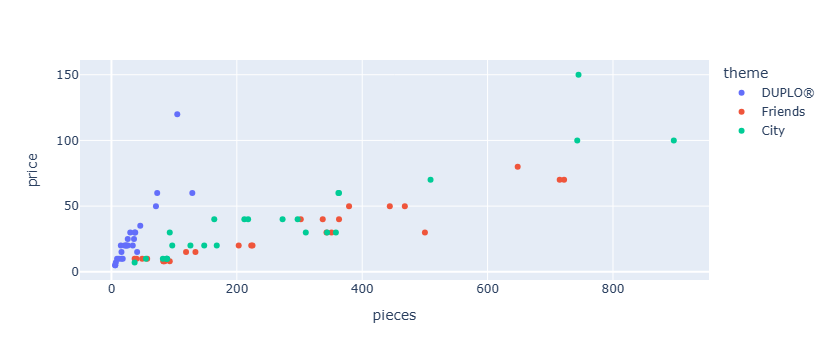

In [23]:
piece_vs_price = px.scatter(DF, 
                            x="pieces", 
                            y="price", 
                            color="theme",
                            hover_data='set_name'
                            )
piece_vs_price.show()

(b) Answer the three questions by describing what you see in the graph. Comment on any points that look like outliers.

The price of a Lego set seems related to the number of pieces because Lego sets with low numbers of pieces seem to have lower prices than Lego sets with high numbers of pieces. The most expensive Lego set is 'Ocean Exploration Ship', costing $149.99. Certain themes seem to dictate different price per piece ratios, highlighted best by the DUPLO® sets costing more per piece, making the DUPLO® set 'Cargo Train' seem like an outlier despite its relative consistency with the other DUPLO® sets.

# Problem 4 (15 points)

Analyze the price differences between the Retail Price and the Amazon Price.

(a) Create a new column in the data frame that measures the price difference between Amazon and Retail.

If the results of this calculation are positive, what does that mean about the prices?

In [24]:
DF['price_difference'] = DF['price'] - DF['amazon_price']
show(DF)

Loading ITables v2.5.2 from the internet... (need help?)


If the difference is positive, then the Lego set is cheaper to buy on Amazon than to buy it retail, but if it's negative, then the set is cheaper to buy retail than to buy on Amazon.

(b) Group the data by Lego Theme and use describe to do statistics on the price difference column you created in part (a). Comment on at least four things that you learned by looking at these statistics.

In [30]:
DF.groupby(by='theme').describe()['price_difference']

,count,mean,std,min,25%,50%,75%,max
theme,,,,,,,,
City,25.0,-5.3996,15.243677,-39.96,-12.00,1.00,4.01,13.99
DUPLO®,25.0,-7.3924,16.996152,-69.00,-11.01,0.00,2.00,5.00
Friends,25.0,-8.9792,24.047927,-115.00,-8.94,-3.96,0.04,9.99


The mean price difference of the Lego Friends sets in the data set is greater than the mean price difference of the other Lego sets. \
On one Lego Friends set, the Amazon price is 115 dollars greater than the retail price. \
The median price difference of Lego City sets is actually positive, meaning that when given a random Lego City set from the data, it is more likely to be cheaper on Amazon than retail. \
One Lego City set is 13.99 cheaper on Amazon, sticking out as a relatively good deal compared to the other Lego sets.

(c) Make a histogram of the price difference and color the bars by the Lego Theme.

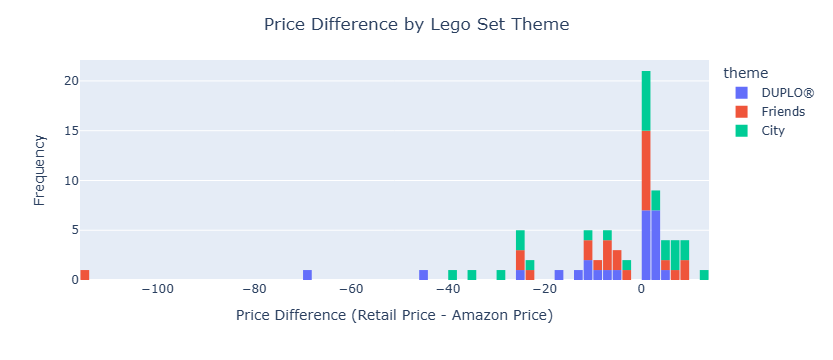

In [39]:
price_difference_histogram = px.histogram(DF,
                  x='price_difference',
                  nbins=100,
                  color='theme'
                  )

price_difference_histogram.update_layout(bargap=0.1,
                  title='Price Difference by Lego Set Theme',
                  title_x=0.5,
                  xaxis_title="Price Difference (Retail Price - Amazon Price)",
                  yaxis_title="Frequency"
                  )

price_difference_histogram.show()

# Problem 5 (20 points)

(a) What was the most expensive set based on Retail price? Show the full data frame information for this observation. Comment on your results comparing Amazon and Retail, number of pieces or minifigs, etc.

In [36]:
DF.sort_values(by='price', ascending=False)

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_difference
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.00
7,10875,Cargo Train,DUPLO®,105,119.99,128.95,2018,Ages_2-5,64,3.0,Box,2.86Kg (6.31 lb),68,Large,-8.96
67,60246,Police Station,City,743,99.99,99.99,2020,Ages_6+,345,7.0,Box,1.85Kg (4.06 lb),298,Small,0.00
72,60258,Tuning Workshop,City,897,99.99,99.99,2020,Ages_6+,389,7.0,Box,1.63Kg (3.58 lb),411,Small,0.00
47,41424,Jungle Rescue Base,Friends,648,79.99,79.95,2020,Ages_8+,176,3.0,Box,NaN,251,Small,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38,41384,Andrea's Summer Heart Box,Friends,83,7.99,14.99,2019,Ages_6+,36,1.0,Other,NaN,46,Small,-7.00
19,10918,Tow Truck,DUPLO®,7,6.99,6.29,2020,Ages_1½+,3,NaN,Box with backing card,NaN,7,Large,0.70
50,60170,Off-Road Chase,City,37,6.99,30.89,2018,Ages_5-12,20,2.0,Box,NaN,28,Small,-23.90
0,10859,My First Ladybird,DUPLO®,6,4.99,16.00,2018,Ages_1½-3,9,NaN,Box,NaN,5,Large,-11.01


The most expensive set when sorting by retail price is 'Ocean Exploration Ship', as I noted in my scatter plot. Its retail and Amazon prices are the same, which is around typical for a Lego City set. While it isn't the Lego set with the most pieces, it has the 2nd most, justifying its position as the most expensive Lego set by retail price.

(b) What was the most expensive set based on Amazon price? Show the full data frame information for this observation.

In [40]:
DF.sort_values(by='amazon_price', ascending=False)

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_difference
28,41340,Friendship House,Friends,722,69.99,184.99,2018,Ages_6-12,164,3.0,Box,1.14Kg (2.51 lb),309,Small,-115.00
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.00
7,10875,Cargo Train,DUPLO®,105,119.99,128.95,2018,Ages_2-5,64,3.0,Box,2.86Kg (6.31 lb),68,Large,-8.96
72,60258,Tuning Workshop,City,897,99.99,99.99,2020,Ages_6+,389,7.0,Box,1.63Kg (3.58 lb),411,Small,0.00
67,60246,Police Station,City,743,99.99,99.99,2020,Ages_6+,345,7.0,Box,1.85Kg (4.06 lb),298,Small,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,41396,Puppy Playground,Friends,57,9.99,8.99,2020,Ages_4+,40,1.0,Box,NaN,41,Small,1.00
70,60251,Monster Truck,City,55,9.99,8.99,2020,Ages_5+,32,1.0,Box,0.14Kg (0.31 lb),34,Small,1.00
69,60249,Street Sweeper,City,89,9.99,8.99,2020,Ages_5+,48,1.0,Box,0.14Kg (0.31 lb),55,Small,1.00
39,41387,Olivia's Summer Heart Box,Friends,93,7.99,7.99,2019,Ages_6+,40,2.0,Other,NaN,48,Small,0.00


(c) How many sets were above $100 on either Retail or Amazon? Show the full data frame information for these observations. Comment on any observations for these sets.

In [52]:
DF_price100 = DF[DF['price']>100]
DF_price100

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_difference
7,10875,Cargo Train,DUPLO®,105,119.99,128.95,2018,Ages_2-5,64,3.0,Box,2.86Kg (6.31 lb),68,Large,-8.96
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.00


In [53]:
DF_amazon_price100 = DF[DF['amazon_price']>100]
DF_amazon_price100

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_difference
7,10875,Cargo Train,DUPLO®,105,119.99,128.95,2018,Ages_2-5,64,3.0,Box,2.86Kg (6.31 lb),68,Large,-8.96
28,41340,Friendship House,Friends,722,69.99,184.99,2018,Ages_6-12,164,3.0,Box,1.14Kg (2.51 lb),309,Small,-115.00
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.00


In [54]:
DF_100 = DF_price100.merge(DF_amazon_price100, how='outer')
DF_100

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_difference
0,10875,Cargo Train,DUPLO®,105,119.99,128.95,2018,Ages_2-5,64,3.0,Box,2.86Kg (6.31 lb),68,Large,-8.96
1,41340,Friendship House,Friends,722,69.99,184.99,2018,Ages_6-12,164,3.0,Box,1.14Kg (2.51 lb),309,Small,-115.00
2,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.00


All the sets that are at least \\$100 retail are \\$100 on amazon, but that doesn't apply to the inverse.

# Problem 6 (20 points)

(a) On average is the price of Legos increasing, decreasing, or staying the same over the three years?

In [65]:
DF.groupby(by='year')[['price', 'amazon_price']].median()

,price,amazon_price
year,,
2018,24.99,40.40
2019,19.99,23.27
2020,29.99,23.98


In [66]:
DF.groupby(by='year')[['price', 'amazon_price']].mean()

,price,amazon_price
year,,
2018,28.772609,52.639130
2019,28.670000,29.217600
2020,38.212222,37.532963


For the average Lego set, the price decreased between 2018 and 2019 before spiking back up in 2020. 

(b) On average are the number of pieces increase, decreasing, or staying the same over the three years?

In [68]:
DF.groupby(by='year')[['pieces']].median()

,pieces
year,
2018,82.0
2019,97.0
2020,126.0


In [69]:
DF.groupby(by='year')[['pieces']].mean()

,pieces
year,
2018,157.913043
2019,193.120000
2020,232.370370


For the average Lego set, the number of pieces increased across each subsuquent year.

(c) Which set has the most minifigures and how many sets have zero or an unknown number of minifigures?

In [70]:
DF.sort_values(by='minifigures', ascending=False)

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_difference
56,60202,People Pack - Outdoor Adventures,City,164,39.99,69.99,2018,Ages_5-12,64,15.0,Box,0.29Kg (0.64 lb),128,Small,-30.00
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.00
72,60258,Tuning Workshop,City,897,99.99,99.99,2020,Ages_6+,389,7.0,Box,1.63Kg (3.58 lb),411,Small,0.00
67,60246,Police Station,City,743,99.99,99.99,2020,Ages_6+,345,7.0,Box,1.85Kg (4.06 lb),298,Small,0.00
66,60245,Police Monster Truck Heist,City,362,59.99,52.74,2020,Ages_5+,200,5.0,Box,0.85Kg (1.87 lb),198,Small,7.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,10885,My First Fun Puzzle,DUPLO®,15,19.99,19.55,2019,Ages_1½+,9,NaN,NaN,NaN,15,Large,0.44
12,10886,My First Car Creations,DUPLO®,34,19.99,16.00,2019,Ages_1½+,10,NaN,NaN,0.64Kg (1.41 lb),31,Large,3.99
14,10904,Baby Animals,DUPLO®,9,9.99,21.11,2019,Ages_2+,8,NaN,Box,NaN,9,Large,-11.12
19,10918,Tow Truck,DUPLO®,7,6.99,6.29,2020,Ages_1½+,3,NaN,Box with backing card,NaN,7,Large,0.70


In [105]:
DF_minifig = DF[DF['minifigures'].isnull()]
DF_minifig[['minifigures']].shape

(10, 1)

The Lego set with the most minifigures is 'People Pack - Outdoor Adventures' and there are 10 Lego sets without an entry for the number of minifigures, implying a lack of minifigures in each.

# Problem 7 (10 points)

Do an analysis that answers the question below. (free form) \
I want to buy some Legos for my 6 year old cousin, which Lego set is the best deal?

* First you will have to describe in words what makes a good deal. Is is price per piece, price per minifig, price per number of unique pieces, price per page, is it some combination of these things? Should you use Retail or Amazon Price?
* Then you will have to decide what age ranges are appropriate and select just that data.
* Then you will need to do a calculation and add that column to your data frame.
* Finally sort your deal column to find the best purchase.

    THERE IS NOT ONE CORRECT ANSWER - your answer should be different from everyone else. What I am looking for here is how you are using your data science skills to answer the question and explaining what you are doing.

In my opinion, the Lego set that is the 'best deal' would have the smalest price per piece ratio since the time time that the child will stay occupied for is dependent on how long it takes them to put it together. Either price should work, so the calculation should use whatever the cheapest price possible is.

In [108]:
DF_eligible_sets = DF[DF['ages'].isin(['Ages_1½+', 'Ages_2+', 'Ages_3+', 'Ages_4+', 'Ages_5+', 'Ages_5-12', 'Ages_6+', 'Ages_6-12'])]
DF_eligible_sets

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_difference
11,10885,My First Fun Puzzle,DUPLO®,15,19.99,19.55,2019,Ages_1½+,9,NaN,NaN,NaN,15,Large,0.44
12,10886,My First Car Creations,DUPLO®,34,19.99,16.00,2019,Ages_1½+,10,NaN,NaN,0.64Kg (1.41 lb),31,Large,3.99
13,10901,Fire Truck,DUPLO®,21,19.99,17.99,2019,Ages_2+,10,2.0,Box,0.45Kg (0.99 lb),16,Large,2.00
14,10904,Baby Animals,DUPLO®,9,9.99,21.11,2019,Ages_2+,8,NaN,Box,NaN,9,Large,-11.12
15,10906,Tropical Island,DUPLO®,73,59.99,59.99,2019,Ages_2+,40,3.0,Box,NaN,44,Large,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,60249,Street Sweeper,City,89,9.99,8.99,2020,Ages_5+,48,1.0,Box,0.14Kg (0.31 lb),55,Small,1.00
70,60251,Monster Truck,City,55,9.99,8.99,2020,Ages_5+,32,1.0,Box,0.14Kg (0.31 lb),34,Small,1.00
71,60252,Construction Bulldozer,City,126,19.99,15.99,2020,Ages_4+,84,2.0,Box,0.35Kg (0.78 lb),81,Small,4.00
72,60258,Tuning Workshop,City,897,99.99,99.99,2020,Ages_6+,389,7.0,Box,1.63Kg (3.58 lb),411,Small,0.00


In [118]:
DF_eligible_sets['best_price'] = DF_eligible_sets[['price', 'amazon_price']].min(axis=1)

DF_eligible_sets

C:\Users\garrr\AppData\Local\Temp\ipykernel_27524\2956247949.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_difference,best_price
11,10885,My First Fun Puzzle,DUPLO®,15,19.99,19.55,2019,Ages_1½+,9,NaN,NaN,NaN,15,Large,0.44,19.55
12,10886,My First Car Creations,DUPLO®,34,19.99,16.00,2019,Ages_1½+,10,NaN,NaN,0.64Kg (1.41 lb),31,Large,3.99,16.00
13,10901,Fire Truck,DUPLO®,21,19.99,17.99,2019,Ages_2+,10,2.0,Box,0.45Kg (0.99 lb),16,Large,2.00,17.99
14,10904,Baby Animals,DUPLO®,9,9.99,21.11,2019,Ages_2+,8,NaN,Box,NaN,9,Large,-11.12,9.99
15,10906,Tropical Island,DUPLO®,73,59.99,59.99,2019,Ages_2+,40,3.0,Box,NaN,44,Large,0.00,59.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,60249,Street Sweeper,City,89,9.99,8.99,2020,Ages_5+,48,1.0,Box,0.14Kg (0.31 lb),55,Small,1.00,8.99
70,60251,Monster Truck,City,55,9.99,8.99,2020,Ages_5+,32,1.0,Box,0.14Kg (0.31 lb),34,Small,1.00,8.99
71,60252,Construction Bulldozer,City,126,19.99,15.99,2020,Ages_4+,84,2.0,Box,0.35Kg (0.78 lb),81,Small,4.00,15.99
72,60258,Tuning Workshop,City,897,99.99,99.99,2020,Ages_6+,389,7.0,Box,1.63Kg (3.58 lb),411,Small,0.00,99.99


In [119]:
DF_eligible_sets['price_per_piece'] = DF_eligible_sets['best_price'] / DF_eligible_sets['pieces']
DF_eligible_sets

C:\Users\garrr\AppData\Local\Temp\ipykernel_27524\1668964079.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_difference,best_price,price_per_piece
11,10885,My First Fun Puzzle,DUPLO®,15,19.99,19.55,2019,Ages_1½+,9,NaN,NaN,NaN,15,Large,0.44,19.55,1.303333
12,10886,My First Car Creations,DUPLO®,34,19.99,16.00,2019,Ages_1½+,10,NaN,NaN,0.64Kg (1.41 lb),31,Large,3.99,16.00,0.470588
13,10901,Fire Truck,DUPLO®,21,19.99,17.99,2019,Ages_2+,10,2.0,Box,0.45Kg (0.99 lb),16,Large,2.00,17.99,0.856667
14,10904,Baby Animals,DUPLO®,9,9.99,21.11,2019,Ages_2+,8,NaN,Box,NaN,9,Large,-11.12,9.99,1.110000
15,10906,Tropical Island,DUPLO®,73,59.99,59.99,2019,Ages_2+,40,3.0,Box,NaN,44,Large,0.00,59.99,0.821781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,60249,Street Sweeper,City,89,9.99,8.99,2020,Ages_5+,48,1.0,Box,0.14Kg (0.31 lb),55,Small,1.00,8.99,0.101011
70,60251,Monster Truck,City,55,9.99,8.99,2020,Ages_5+,32,1.0,Box,0.14Kg (0.31 lb),34,Small,1.00,8.99,0.163455
71,60252,Construction Bulldozer,City,126,19.99,15.99,2020,Ages_4+,84,2.0,Box,0.35Kg (0.78 lb),81,Small,4.00,15.99,0.126905
72,60258,Tuning Workshop,City,897,99.99,99.99,2020,Ages_6+,389,7.0,Box,1.63Kg (3.58 lb),411,Small,0.00,99.99,0.111472


In [121]:
DF_eligible_sets.sort_values(by='price_per_piece', ascending=True)

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_difference,best_price,price_per_piece
29,41353,Friends Advent Calendar,Friends,500,29.99,34.00,2018,Ages_6-12,4,NaN,Box,NaN,202,Small,-4.01,29.99,0.059980
63,60223,Harvester Transport,City,358,29.99,54.80,2019,Ages_5+,148,3.0,Box,0.65Kg (1.43 lb),166,Small,-24.81,29.99,0.083771
27,41335,Mia's Tree House,Friends,351,29.99,53.88,2018,Ages_6-12,120,2.0,Box,0.61Kg (1.34 lb),151,Small,-23.89,29.99,0.085442
35,41374,Andrea's Pool Party,Friends,468,49.99,40.00,2019,Ages_6+,112,2.0,Box,NaN,221,Small,9.99,40.00,0.085470
39,41387,Olivia's Summer Heart Box,Friends,93,7.99,7.99,2019,Ages_6+,40,2.0,Other,NaN,48,Small,0.00,7.99,0.085914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,10918,Tow Truck,DUPLO®,7,6.99,6.29,2020,Ages_1½+,3,NaN,Box with backing card,NaN,7,Large,0.70,6.29,0.898571
20,10921,Super Heroes Lab,DUPLO®,30,29.99,26.99,2020,Ages_2+,16,3.0,Box,NaN,23,Large,3.00,26.99,0.899667
21,10926,Bedroom,DUPLO®,16,14.99,14.99,2020,Ages_2+,2,2.0,Box,NaN,16,Large,0.00,14.99,0.936875
14,10904,Baby Animals,DUPLO®,9,9.99,21.11,2019,Ages_2+,8,NaN,Box,NaN,9,Large,-11.12,9.99,1.110000


According to the Price Per Piece Ratio (PPP Ratio), the best deal for your 6 year old cousin would be the 'Friends Advent Calendar' from the Lego Friends collection.